In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

PROJECT_ROOT = Path("../")
results_path = PROJECT_ROOT / "results" / "experiments.csv"

df = pd.read_csv(results_path)
df

,model_name,accuracy,macro_f1,weighted_f1,akiec_precision,akiec_recall,akiec_f1,akiec_support,bcc_precision,bcc_recall,...,mel_f1,mel_support,nv_precision,nv_recall,nv_f1,nv_support,vasc_precision,vasc_recall,vasc_f1,vasc_support
0,baseline_model,0.837335,0.729056,0.833673,0.678571,0.558824,0.612903,68.0,0.827869,0.765152,...,0.592771,225.0,0.905045,0.937020,0.920755,1302.0,0.767442,0.916667,0.835443,36.0
1,baseline_model_1.5,0.840274,0.733328,0.839539,0.676923,0.647059,0.661654,68.0,0.775362,0.810606,...,0.643172,225.0,0.916283,0.916283,0.916283,1302.0,0.756098,0.861111,0.805195,36.0
2,augmented_model,0.783929,0.694522,0.796678,0.556962,0.647059,0.598639,68.0,0.810345,0.712121,...,0.558730,225.0,0.938380,0.818740,0.874487,1302.0,0.708333,0.944444,0.809524,36.0
3,focal_model,0.635963,0.612738,0.658512,0.519481,0.588235,0.551724,68.0,0.600000,0.863636,...,0.466488,225.0,0.976871,0.551459,0.704958,1302.0,0.516129,0.888889,0.653061,36.0
4,resnet34_baseline,0.585007,0.488831,0.625103,0.367647,0.367647,0.367647,68.0,0.443038,0.795455,...,0.438596,225.0,0.973937,0.545315,0.699163,1302.0,0.491803,0.833333,0.618557,36.0
5,resnet34_mask_crop,0.773150,0.718953,0.788444,0.602564,0.691176,0.643836,68.0,0.753247,0.878788,...,0.512000,225.0,0.940693,0.791859,0.859883,1302.0,0.755556,0.944444,0.839506,36.0
6,efficientnet_mask_crop,0.838315,0.745301,0.838600,0.540230,0.691176,0.606452,68.0,0.792208,0.924242,...,0.599099,225.0,0.919719,0.906298,0.912959,1302.0,0.825000,0.916667,0.868421,36.0


In [2]:
df = df.sort_values(by="macro_f1", ascending=False)
df[["model_name", "accuracy", "macro_f1", "weighted_f1"]]

,model_name,accuracy,macro_f1,weighted_f1
6,efficientnet_mask_crop,0.838315,0.745301,0.838600
1,baseline_model_1.5,0.840274,0.733328,0.839539
0,baseline_model,0.837335,0.729056,0.833673
5,resnet34_mask_crop,0.773150,0.718953,0.788444
2,augmented_model,0.783929,0.694522,0.796678
3,focal_model,0.635963,0.612738,0.658512
4,resnet34_baseline,0.585007,0.488831,0.625103


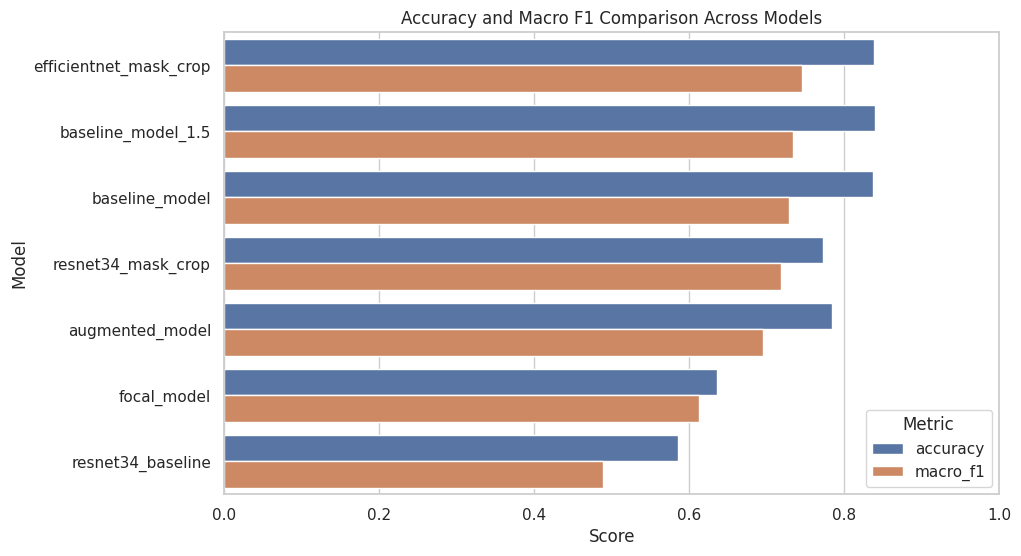

In [3]:
# plot accuracy and f1 scores

plt.figure(figsize=(10,6))
sns.barplot(
    data=df.melt(id_vars="model_name", value_vars=["accuracy", "macro_f1"], var_name="metric", value_name="score"),
    x="score",
    y="model_name",
    hue="metric"
)
plt.title("Accuracy and Macro F1 Comparison Across Models")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.show()

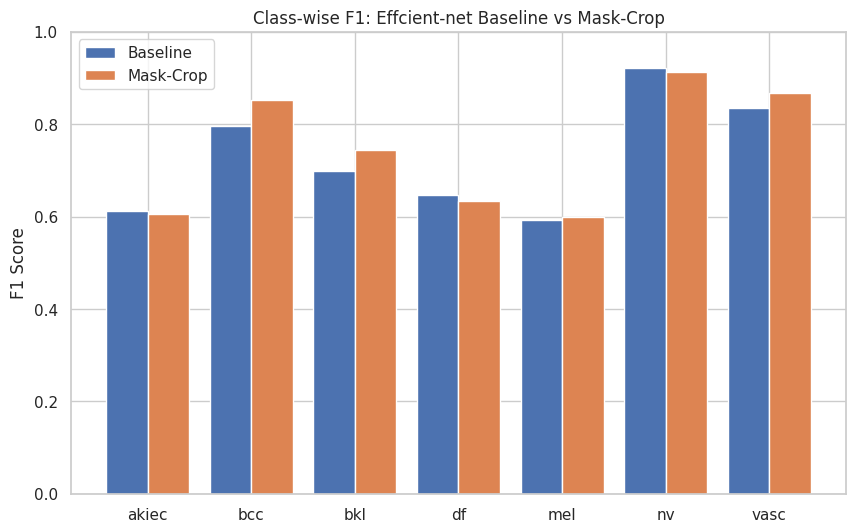

In [4]:
# Classwise f1 comparison

baseline = df[df["model_name"] == "baseline_model"]
mask_crop = df[df["model_name"] == "efficientnet_mask_crop"]

classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

baseline_f1 = [baseline[f"{c}_f1"].values[0] for c in classes]
mask_f1 = [mask_crop[f"{c}_f1"].values[0] for c in classes]

x = range(len(classes))

plt.figure(figsize=(10,6))
plt.bar(x, baseline_f1, width=0.4, label="Baseline", align='center')
plt.bar([i+0.4 for i in x], mask_f1, width=0.4, label="Mask-Crop", align='center')

plt.xticks([i+0.2 for i in x], classes)
plt.ylabel("F1 Score")
plt.title("Class-wise F1: Effcient-net Baseline vs Mask-Crop")
plt.legend()
plt.ylim(0,1)
plt.show()

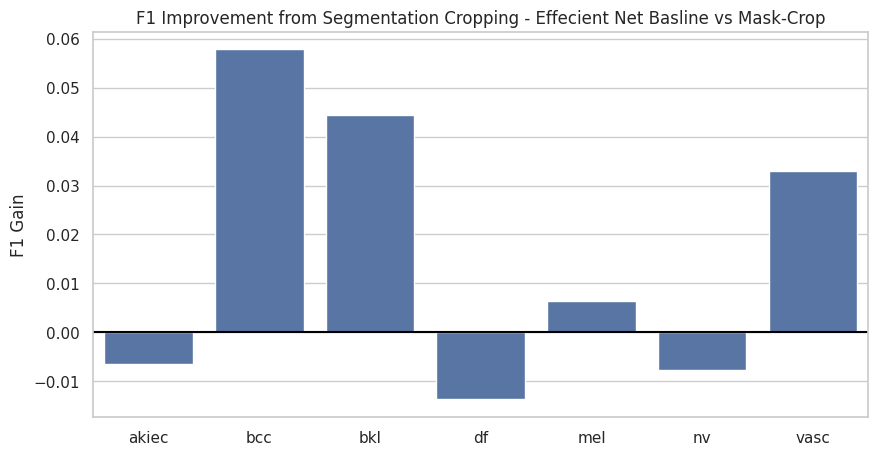

In [14]:
# improvement plot

improvement = [m - b for m, b in zip(mask_f1, baseline_f1)]

plt.figure(figsize=(10,5))
sns.barplot(x=classes, y=improvement)
plt.axhline(0, color='black')
plt.title("F1 Improvement from Segmentation Cropping - Effecient Net Basline vs Mask-Crop")
plt.ylabel("F1 Gain")
plt.show()

In [9]:
# Compare f1 scores of all the models saved in the results.csv with numbers

import plotly.express as px

df_long = df.melt(id_vars="model_name", value_vars=[f"{c}_f1" for c in classes], var_name="class", value_name="f1_score")
df_long["class"] = df_long["class"].str.replace("_f1", "") 
fig = px.bar(df_long, x="class", y="f1_score", color="model_name", barmode="group",
                 title="Class-wise F1 Scores Across Models")
fig.update_layout(yaxis_title="F1 Score", xaxis_title="Class")
fig.show()


In [7]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# Load results
PROJECT_ROOT = Path("../")
results_path = PROJECT_ROOT / "results" / "experiments.csv"

df = pd.read_csv(results_path)

# Sort by macro F1 (best at top)
df = df.sort_values(by="macro_f1", ascending=False)

# Interactive bar plot
fig = px.bar(
    df,
    x="macro_f1",
    y="model_name",
    orientation="h",
    text="macro_f1",
    hover_data=["accuracy", "weighted_f1"],
    title="Macro F1 Comparison Across Classification Models"
)

fig.update_layout(
    xaxis_title="Macro F1 Score",
    yaxis_title="Model",
    xaxis=dict(range=[0,1]),
    height=500
)

fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")

fig.show()

In [13]:
# compare f1 scores of all models in a dataframe

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("../")
results_path = PROJECT_ROOT / "results" / "experiments.csv"
df = pd.read_csv(results_path)

df = df.sort_values(by="macro_f1", ascending=False)
df[["model_name", "accuracy", "macro_f1", "weighted_f1", "accuracy"]]

,model_name,accuracy,macro_f1,weighted_f1,accuracy
6,efficientnet_mask_crop,0.838315,0.745301,0.838600,0.838315
1,baseline_model_1.5,0.840274,0.733328,0.839539,0.840274
0,baseline_model,0.837335,0.729056,0.833673,0.837335
5,resnet34_mask_crop,0.773150,0.718953,0.788444,0.773150
2,augmented_model,0.783929,0.694522,0.796678,0.783929
3,focal_model,0.635963,0.612738,0.658512,0.635963
4,resnet34_baseline,0.585007,0.488831,0.625103,0.585007
